<a href="https://colab.research.google.com/github/dhivyamohan92/Social-Media-Engagement-Analytics-Using-Python/blob/main/%E2%80%9CSocial_Media_Engagement_Analytics%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv")
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


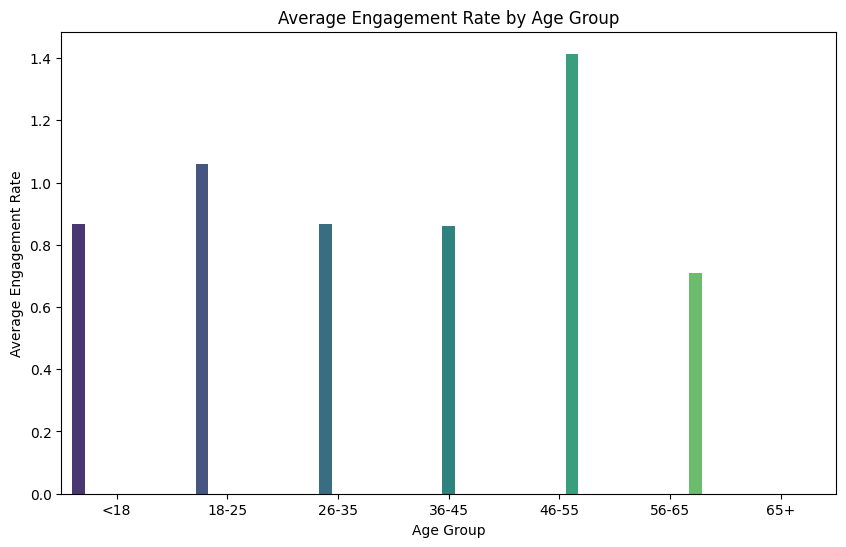

In [54]:
age_engagement = df.groupby("age_group", observed=True)["engagement_rate"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x="age_group", y="engagement_rate", data=age_engagement, palette="viridis", hue="age_group", legend=False)
plt.title("Average Engagement Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Engagement Rate")
plt.show()

In [2]:
# displyinfo
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [3]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [4]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348


In [5]:
for col in ["age", "likes", "comments", "shares"] :df[col]=df[col].fillna(df[col].median())
for col in ["gender", "sentiment"] : df[col]=df[col].fillna(df[col].mode()[0])
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
for col in ["gender", "country", "post_type", "post_category", "device_type", "sentiment"]:
    print(col, ":", df[col].unique())

gender : ['Female' 'Male' 'Other']
country : ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
post_type : ['image' 'reel' 'text' 'video']
post_category : ['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
device_type : ['mobile' 'tablet' 'desktop']
sentiment : ['negative' 'positive' 'neutral']


In [8]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [9]:
for col in ["age", "likes", "comments", "shares"]:
    df[col] = df[col].astype(int)
df["posted_at"] = pd.to_datetime(df["posted_at"])
df.dtypes

/tmp/ipykernel_1677/4267284980.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["posted_at"] = pd.to_datetime(df["posted_at"])


,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [10]:
df["hashtags"].head()

,hashtags
0,#foodie #travel #love
1,#fitness
2,#foodie
3,#music #foodie #fun
4,#travel


In [11]:
df["hashtag_count"] = df["hashtags"].fillna("").apply(lambda x: len(x.split()))
print(df[["hashtags","hashtag_count"]])

                         hashtags  hashtag_count
0           #foodie #travel #love              3
1                        #fitness              1
2                         #foodie              1
3             #music #foodie #fun              3
4                         #travel              1
...                           ...            ...
4995                 #travel #fun              2
4996               #foodie #reels              2
4997             #lifestyle #tech              2
4998        #reels #love #fitness              3
4999  #foodie #lifestyle #fashion              3

[5000 rows x 2 columns]


In [12]:
df["sentiment"]= df["sentiment"].str.strip().str.lower()
df.sentiment

,sentiment
0,negative
1,negative
2,positive
3,negative
4,negative
...,...
4995,positive
4996,negative
4997,positive
4998,positive


In [13]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [14]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [15]:
print("Shape:",df.shape)
print("Column:\n",df.columns)
print("info:\n",df.info)
print("datatypes:\n",df.dtypes)




Shape: (5000, 20)
Column:
 Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')
info:
 <bound method DataFrame.info of       user_id  age  gender    country  post_id post_type post_category  likes  \
0       25795   43  Female     Brazil   496713     image       fitness   7011   
1       10860   33    Male     Brazil   157326      reel          food  11750   
2       86820   32  Female         UK   109864      text          food   4862   
3       64886   51   Other     France   848877      text       fitness   5350   
4       16265   34   Other         UK   449706     image       fitness  12682   
...       ...  ...     ...        ...      ...       ...           ...    ...   
4995    59500   44    Male  Australia 

In [16]:
# Analyze categorical distributions

for col in ["gender", "country", "post_type", "post_category", "device_type", "sentiment", "is_verified"]:
    print(f"\n----- {col.upper()} -----")
    print("Unique Values:", df[col].unique())
    print("Number of Categories:", df[col].nunique())
    print("Value Counts:")
    print(df[col].value_counts())


----- GENDER -----
Unique Values: ['Female' 'Male' 'Other']
Number of Categories: 3
Value Counts:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

----- COUNTRY -----
Unique Values: ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
Number of Categories: 10
Value Counts:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

----- POST_TYPE -----
Unique Values: ['image' 'reel' 'text' 'video']
Number of Categories: 4
Value Counts:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

----- POST_CATEGORY -----
Unique Values: ['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
Number of Categories: 8
Value Counts:
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
tr

In [17]:
# Create correlation matrix
correlation_matrix = df.select_dtypes(include="number").corr()

# Display correlation matrix
correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036323,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036323,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093521,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093521,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


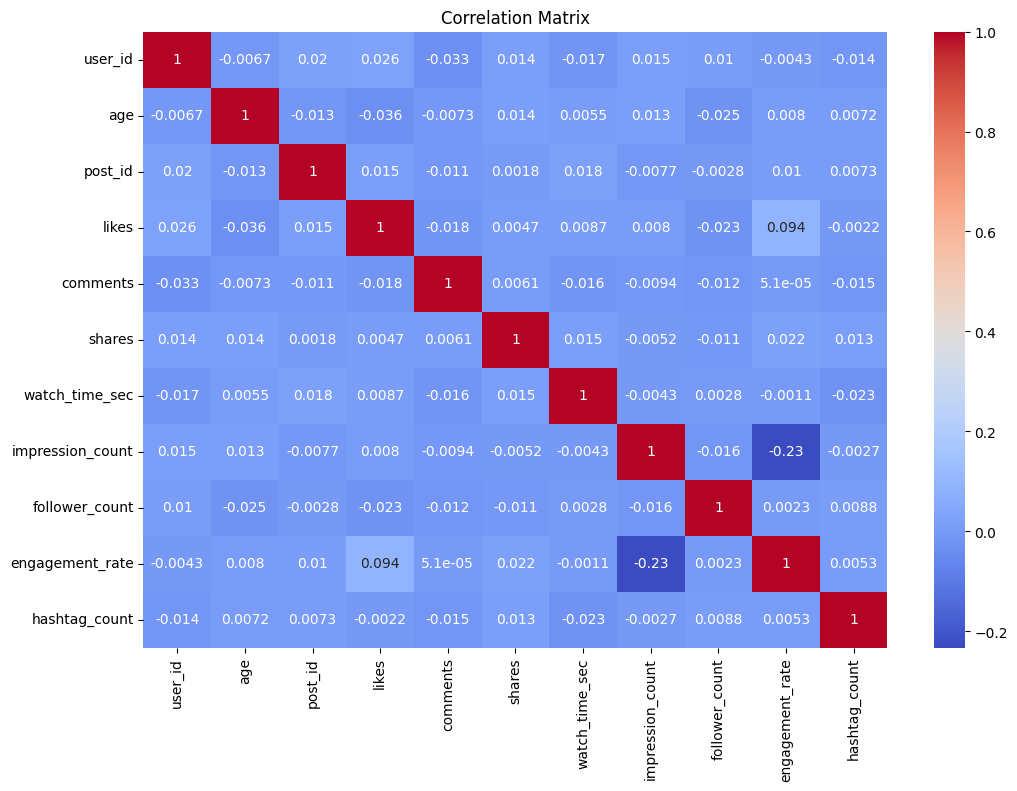

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [19]:
# Use groupby() to summarize metrics
# df.groupby("post_category")["engagement_rate"].mean().sort_values(ascending=False)
df.groupby("post_category")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
post_category,
food,1.358628
tech,1.160475
lifestyle,1.091019
music,0.888803
fitness,0.865628
education,0.844222
fashion,0.807109
travel,0.702223


In [20]:
#B. Best-performing content category
df.groupby("post_category")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
post_category,
food,1.358628
tech,1.160475
lifestyle,1.091019
music,0.888803
fitness,0.865628
education,0.844222
fashion,0.807109
travel,0.702223


In [21]:
# C. Countries with highest average engagement rate
df.groupby("country")["engagement_rate"].mean().sort_values(ascending=False)

,engagement_rate
country,
Brazil,1.540704
Australia,1.324339
France,1.146402
UAE,1.112352
Canada,0.916659
UK,0.850966
Japan,0.769623
Germany,0.759000
India,0.655005


In [25]:
# User Trends

# 4. Create age groups
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ["<18", "18-25", "26-35", "36-45", "46-55", "56-65", "65+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)




In [26]:
# Engagement by age group
df.groupby("age_group", observed=True)["engagement_rate"].mean()


,engagement_rate
age_group,
<18,0.867038
18-25,1.059536
26-35,0.865316
36-45,0.860741
46-55,1.414058
56-65,0.709213


In [27]:
# 5. Verified vs non-verified performance
df.groupby("is_verified")["engagement_rate"].mean()

,engagement_rate
is_verified,
False,0.954744
True,1.054250


In [28]:
# 6. Extract posting hour
df["post_hour"] = df["posted_at"].dt.hour

# Impressions by hour
df.groupby("post_hour")["impression_count"].mean().sort_values(ascending=False)


,impression_count
post_hour,
0,50013.7328


In [55]:
impressions_by_hour = df.groupby("post_hour")["impression_count"].mean().sort_values(ascending=False)

print("Average Impression Count by Post Hour (Sorted):")
print(impressions_by_hour)

best_hour_impressions = impressions_by_hour.index[0]
max_impressions = impressions_by_hour.iloc[0]

print(f"\n \n The best time of day for impressions is hour {best_hour_impressions} with an average of {max_impressions:.2f} impressions.")

Average Impression Count by Post Hour (Sorted):
post_hour
0    50013.7328
Name: impression_count, dtype: float64

 
 The best time of day for impressions is hour 0 with an average of 50013.73 impressions.


In [29]:
# 7. Watch time by device
df.groupby("device_type")["watch_time_sec"].mean().sort_values(ascending=False)


,watch_time_sec
device_type,
mobile,4087.830760
tablet,3979.736429
desktop,3974.792521


In [30]:
# Sentiment Analysis

# 8. Performance by sentiment
df.groupby("sentiment")["engagement_rate"].mean().sort_values(ascending=False)


,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.919744


In [31]:
# 9. Negative and neutral post behavior
df[df["sentiment"].isin(["negative", "neutral"])].groupby("sentiment")[["likes", "comments", "shares", "impression_count", "engagement_rate"]].mean()

,likes,comments,shares,impression_count,engagement_rate
sentiment,,,,,
negative,10208.081250,1516.094792,1007.307292,50191.960417,1.038486
neutral,9923.180092,1528.404060,996.565160,49515.971185,0.991170


In [32]:
#Merge
likes_summary = df.groupby("post_type")["likes"].mean().reset_index(name="avg_likes")

engagement_summary = df.groupby("post_type")["engagement_rate"].mean().reset_index(name="avg_engagement")

final_summary = pd.merge(likes_summary, engagement_summary, on="post_type")

final_summary

,post_type,avg_likes,avg_engagement
0,image,10104.852446,0.895646
1,reel,10037.784879,0.783047
2,text,10100.132530,1.064549
3,video,10188.586122,1.122365


In [33]:
columns = ["likes", "comments", "shares", "watch_time_sec",
           "engagement_rate", "follower_count"]

stats = pd.DataFrame({
    "Mean": df[columns].mean(),
    "Median": df[columns].median(),
    "Mode": df[columns].mode().iloc[0],
    "Standard Deviation": df[columns].std(),
    "Variance": df[columns].var(),
    "25th Percentile": df[columns].quantile(0.25),
    "50th Percentile": df[columns].quantile(0.50),
    "75th Percentile": df[columns].quantile(0.75),
    "90th Percentile": df[columns].quantile(0.90),
    "Skewness": df[columns].skew(),
    "Kurtosis": df[columns].kurt()
})

stats

,Mean,Median,Mode,Standard Deviation,Variance,25th Percentile,50th Percentile,75th Percentile,90th Percentile,Skewness,Kurtosis
likes,10106.982400,10105.000000,10105.000000,5702.293022,3.251615e+07,5235.000000,10105.000000,14959.000000,18016.3000,-0.006886,-1.149992
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000,2695.1000,0.003802,-1.144375
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000,1795.1000,-0.014654,-1.146857
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000,7212.1000,-0.018196,-1.195652
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794,1.2012,18.781271,482.991739
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000,717755.9000,0.041118,-1.189474


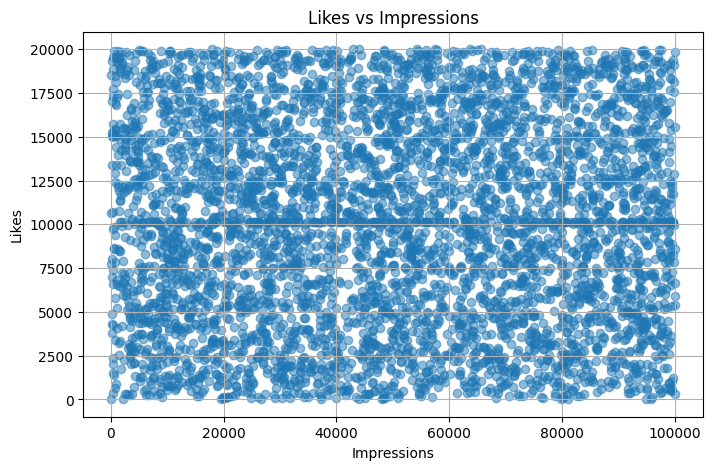

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["impression_count"], df["likes"], alpha=0.5)

plt.title("Likes vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.grid(True)
plt.show()

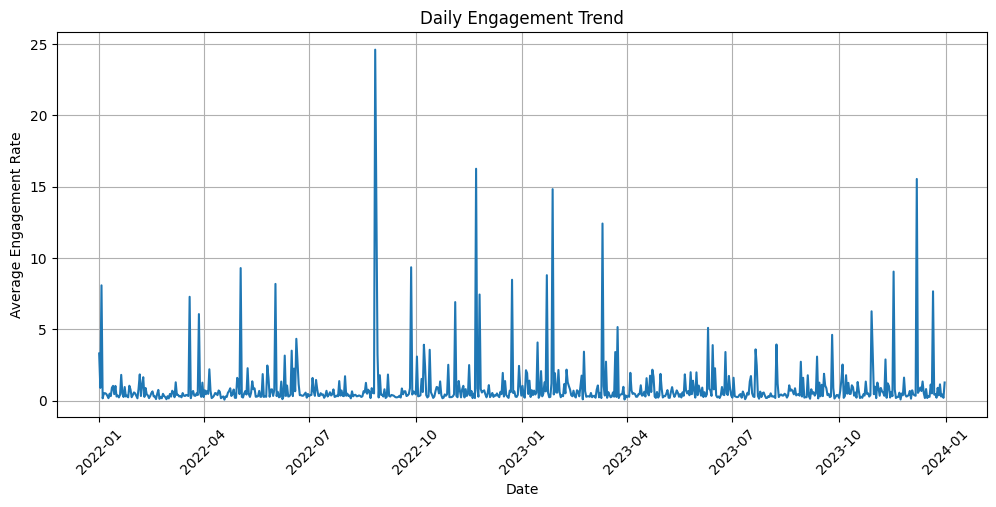

In [35]:
daily_engagement = df.groupby(
    df["posted_at"].dt.date
)["engagement_rate"].mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_engagement.index, daily_engagement.values)

plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Average Engagement Rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

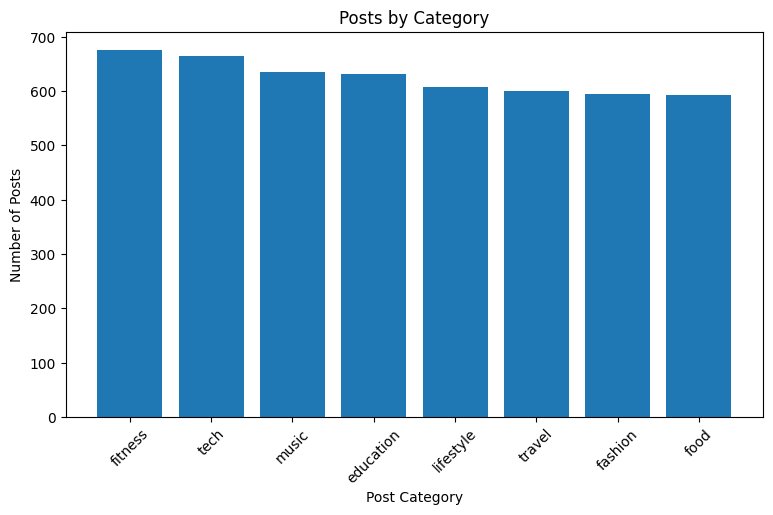

In [36]:
category_count = df["post_category"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(category_count.index, category_count.values)

plt.title("Posts by Category")
plt.xlabel("Post Category")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.show()

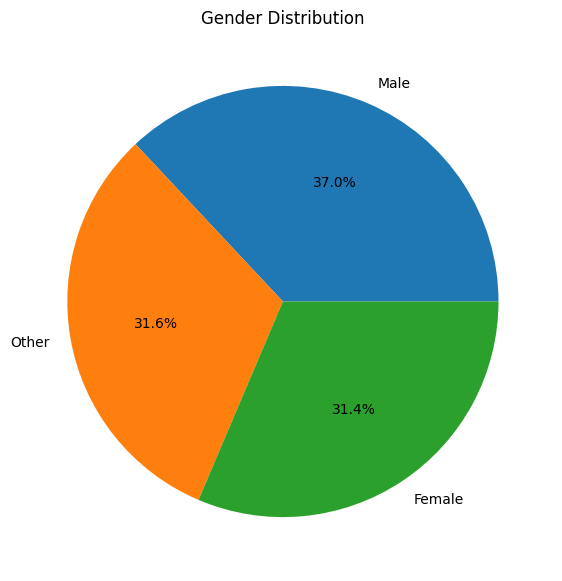

In [37]:
gender_count = df["gender"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()

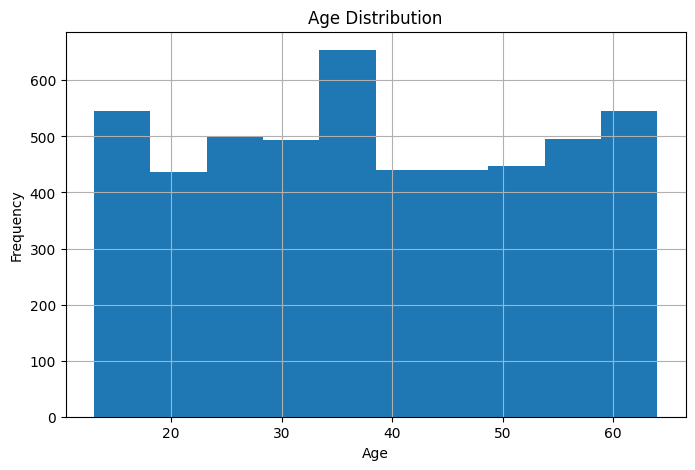

In [38]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

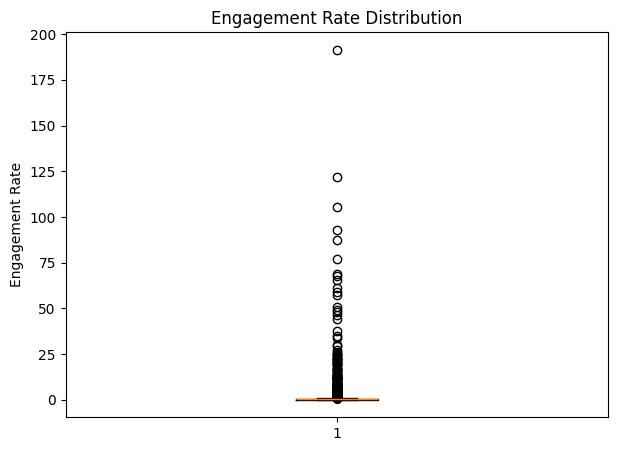

In [39]:
plt.figure(figsize=(7, 5))
plt.boxplot(df["engagement_rate"])

plt.title("Engagement Rate Distribution")
plt.ylabel("Engagement Rate")
plt.show()

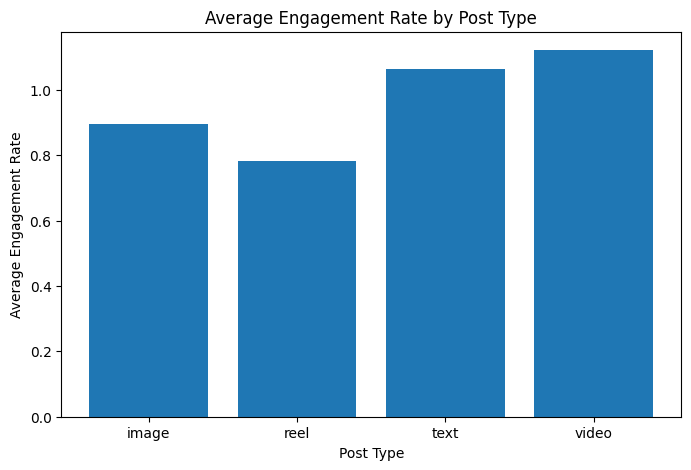

In [40]:
post_type_engagement = df.groupby("post_type")["engagement_rate"].mean()

plt.figure(figsize=(8, 5))
plt.bar(post_type_engagement.index, post_type_engagement.values)

plt.title("Average Engagement Rate by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Average Engagement Rate")
plt.show()

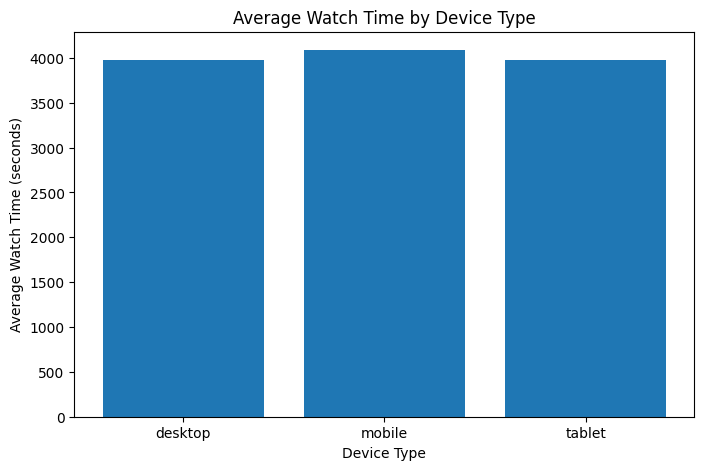

In [41]:
device_watch = df.groupby("device_type")["watch_time_sec"].mean()

plt.figure(figsize=(8, 5))
plt.bar(device_watch.index, device_watch.values)

plt.title("Average Watch Time by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Watch Time (seconds)")
plt.show()

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

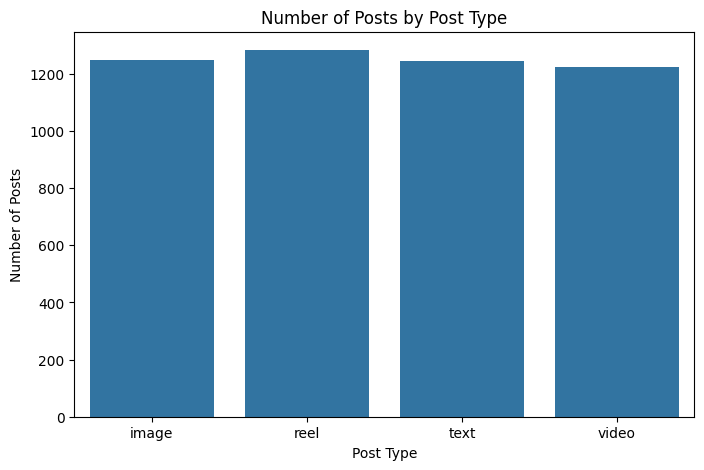

In [43]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="post_type")

plt.title("Number of Posts by Post Type")
plt.xlabel("Post Type")
plt.ylabel("Number of Posts")
plt.show()

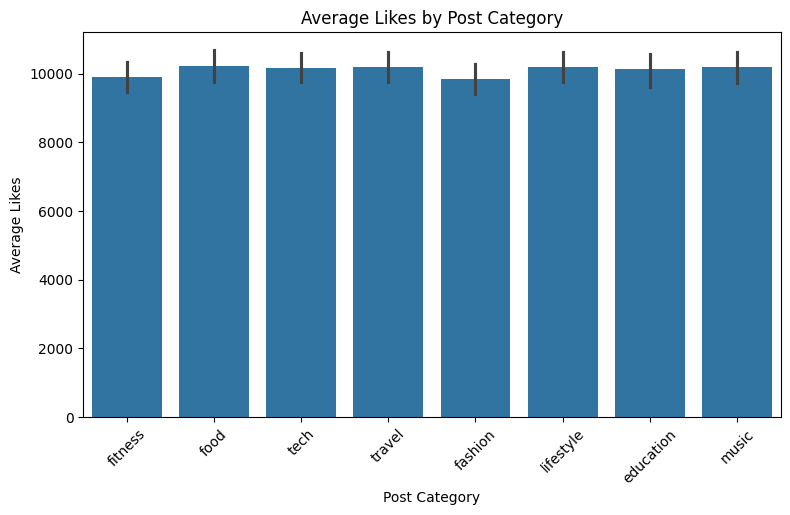

In [44]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="post_category",
    y="likes",
    estimator="mean"
)

plt.title("Average Likes by Post Category")
plt.xlabel("Post Category")
plt.ylabel("Average Likes")
plt.xticks(rotation=45)
plt.show()

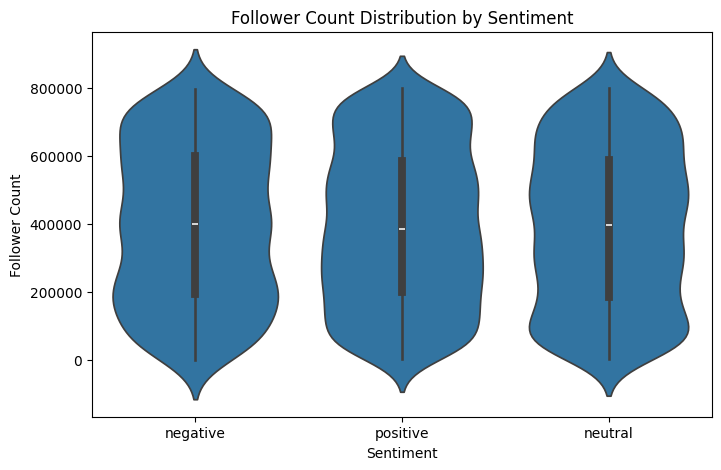

In [45]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)

plt.title("Follower Count Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Follower Count")
plt.show()

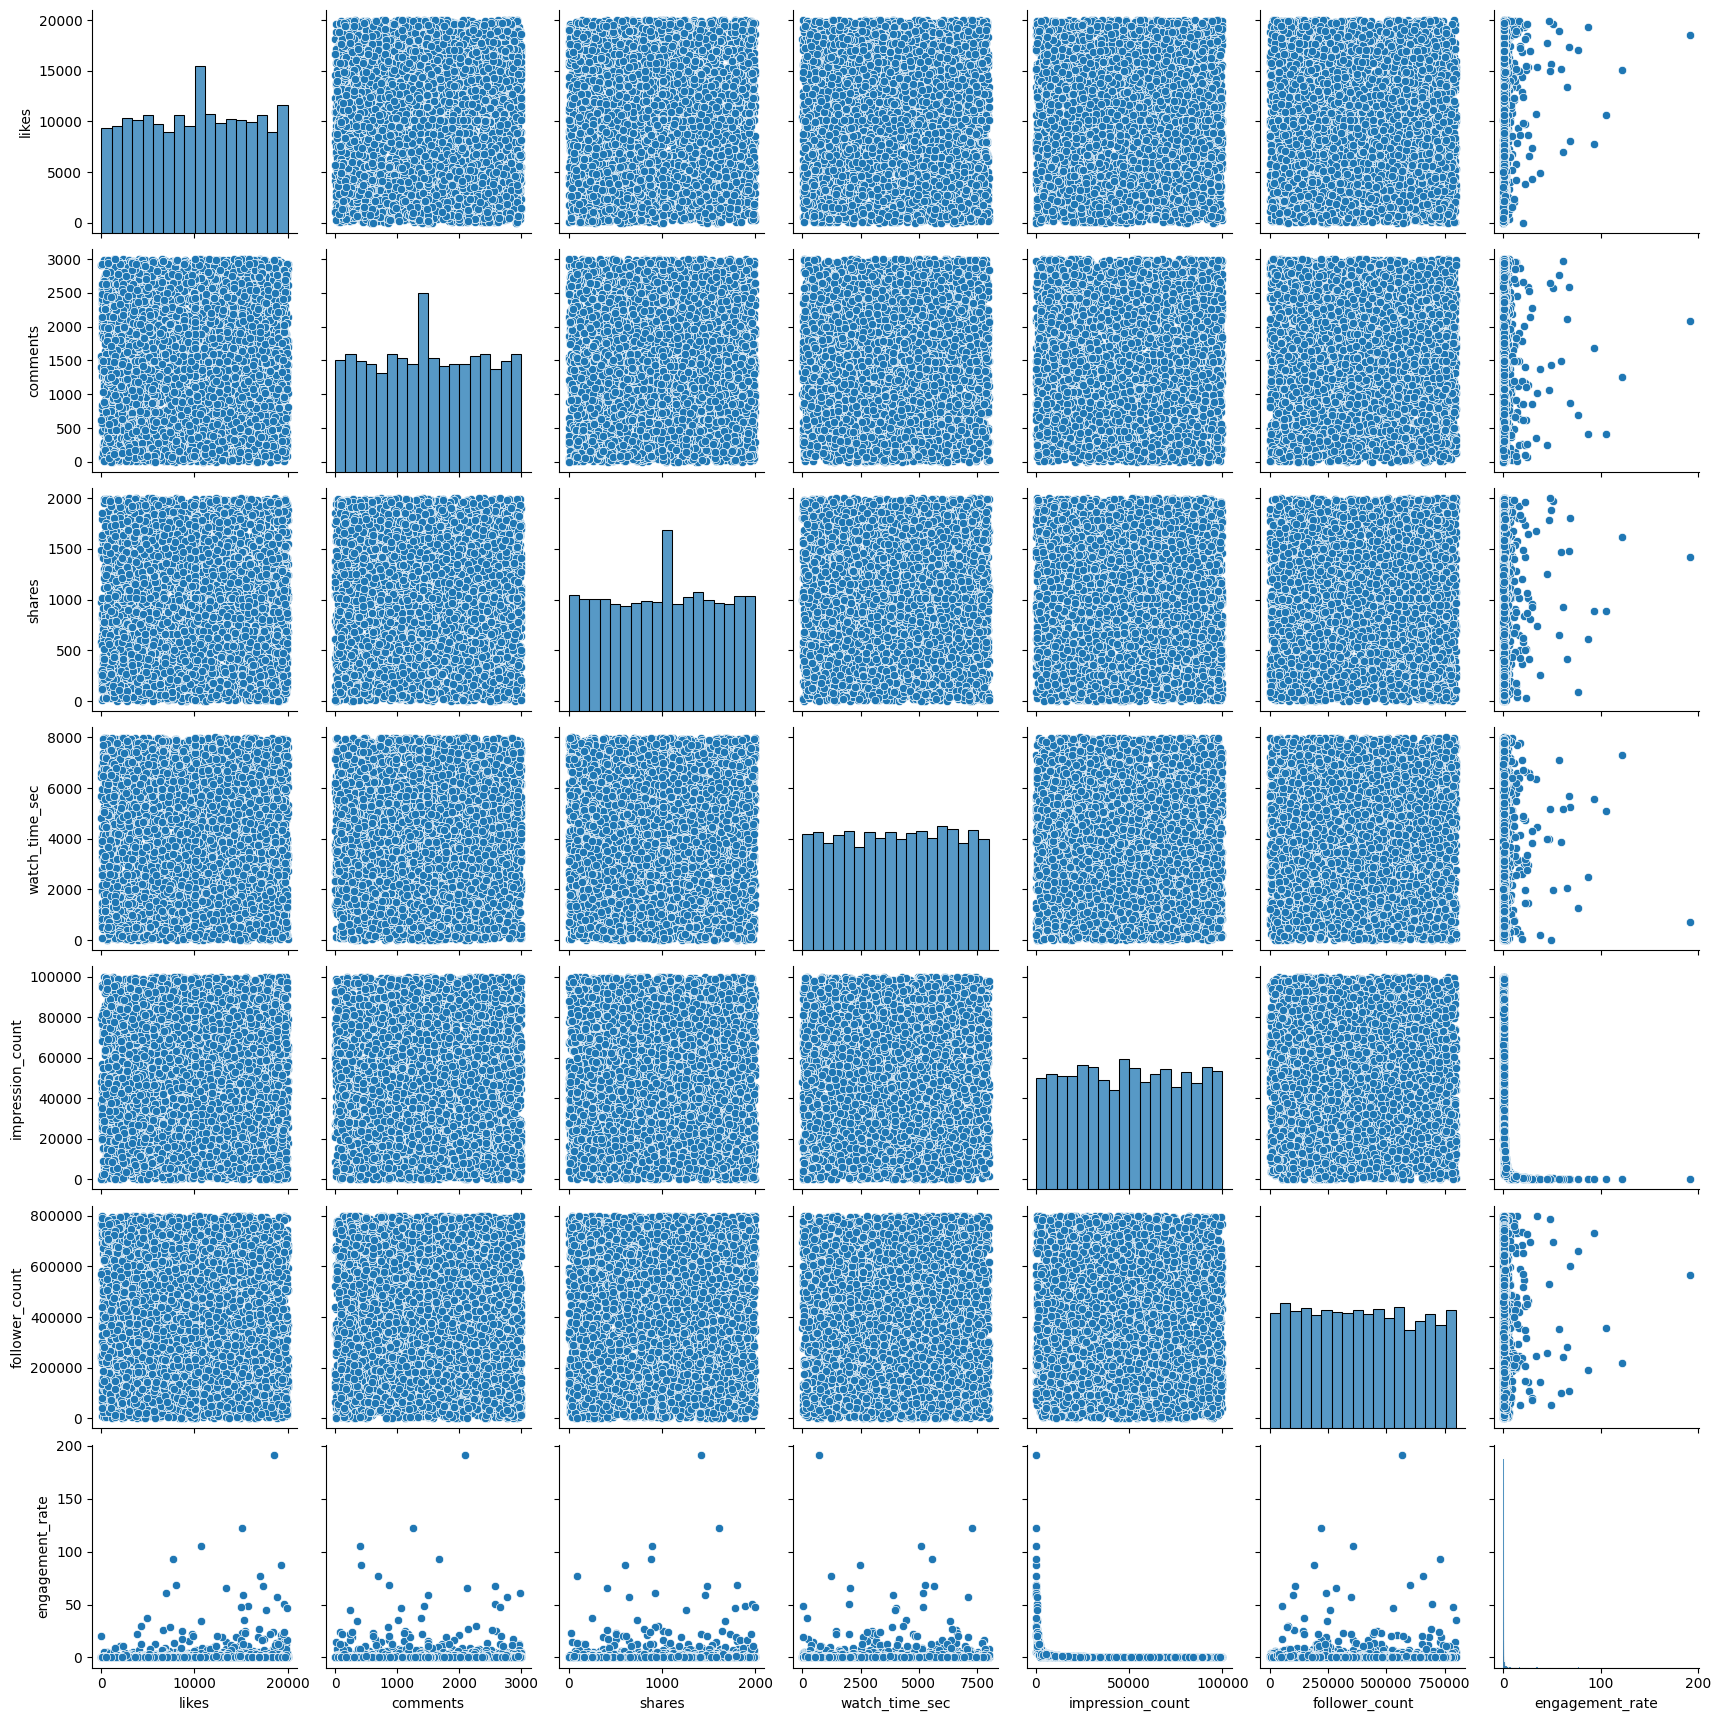

In [46]:
numeric_cols = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "impression_count",
    "follower_count",
    "engagement_rate"
]

sns.pairplot(df[numeric_cols])

plt.show()

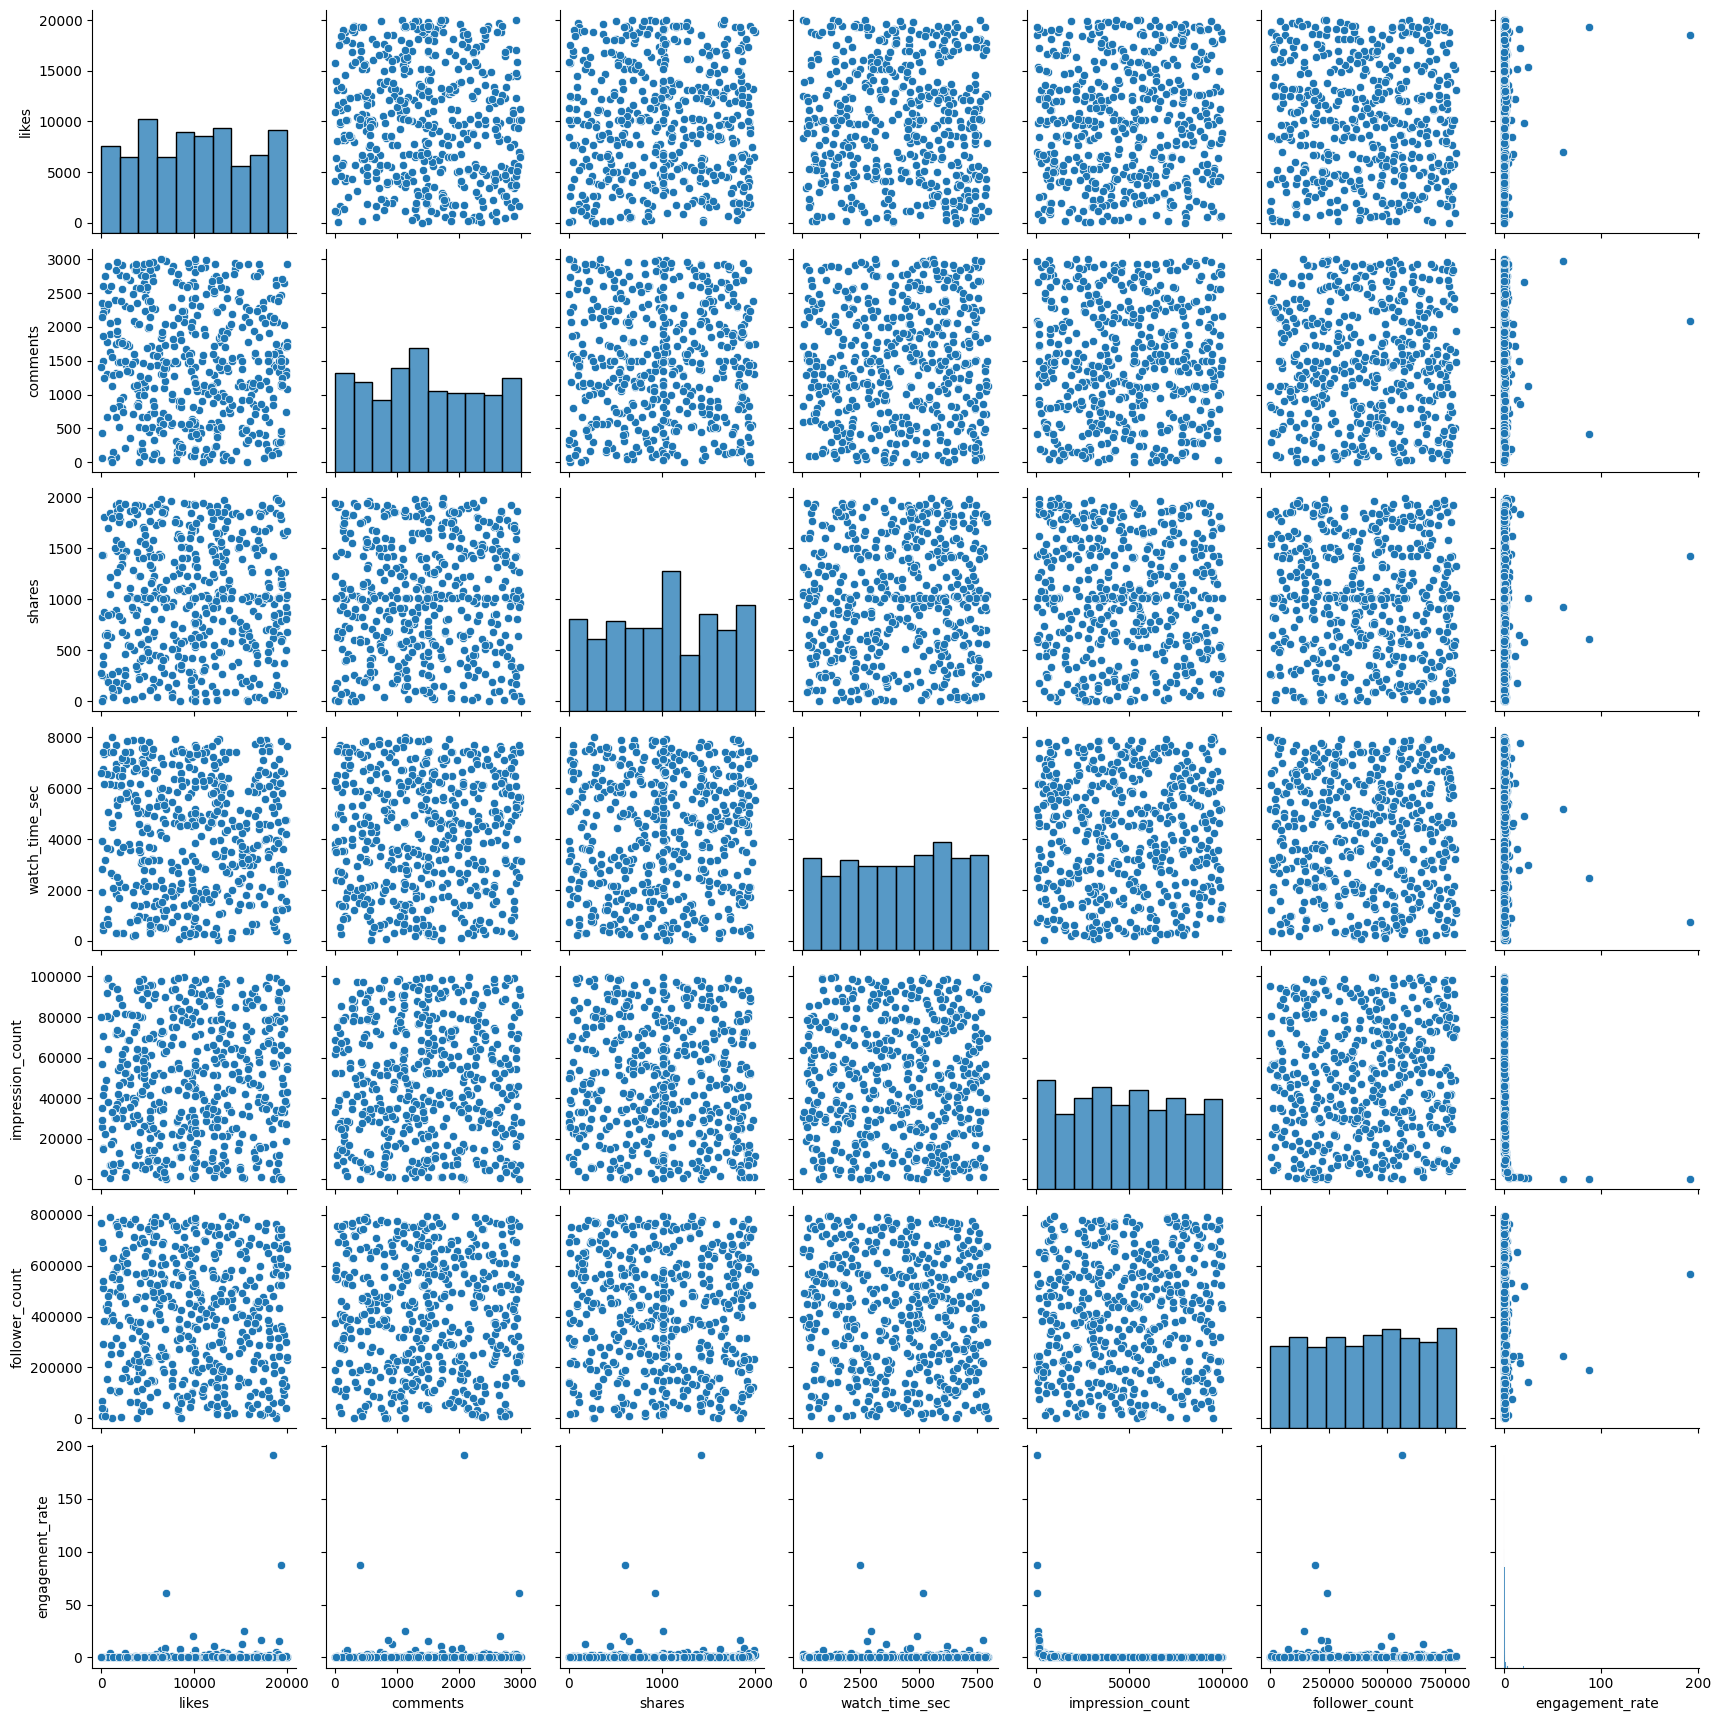

In [47]:
sns.pairplot(df[numeric_cols].sample(500))

plt.show()

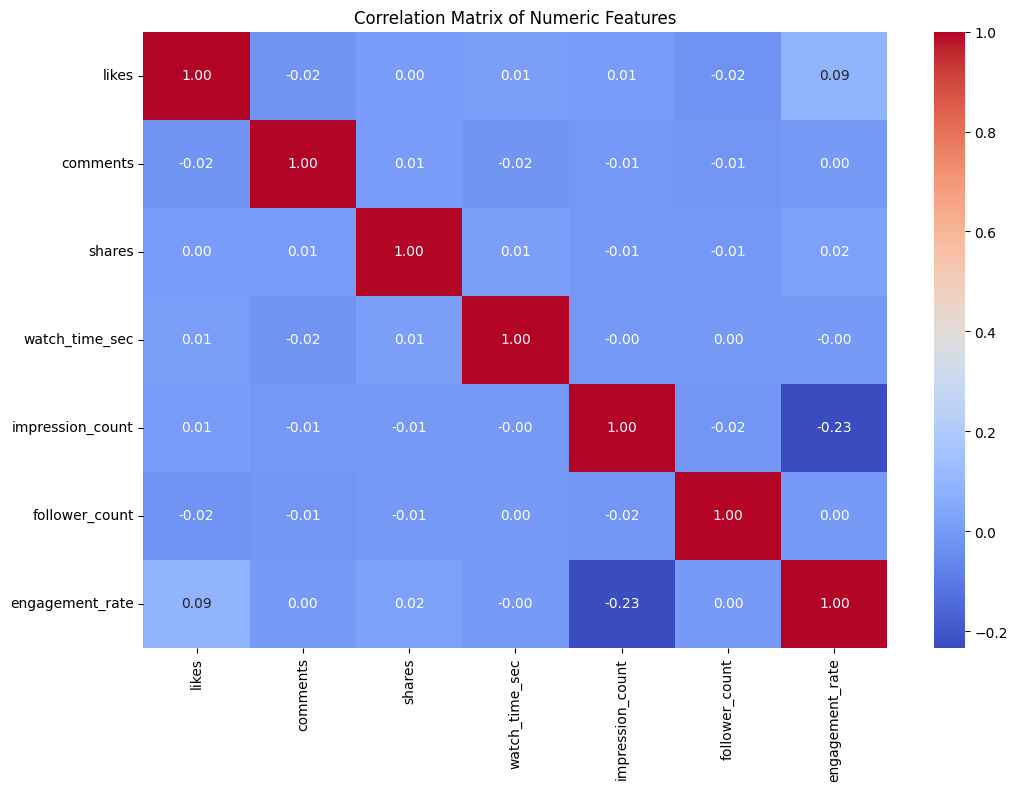

In [48]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numeric Features")
plt.show()

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 67.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 68.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 63.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 71.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 73.4% of the points cannot be plac

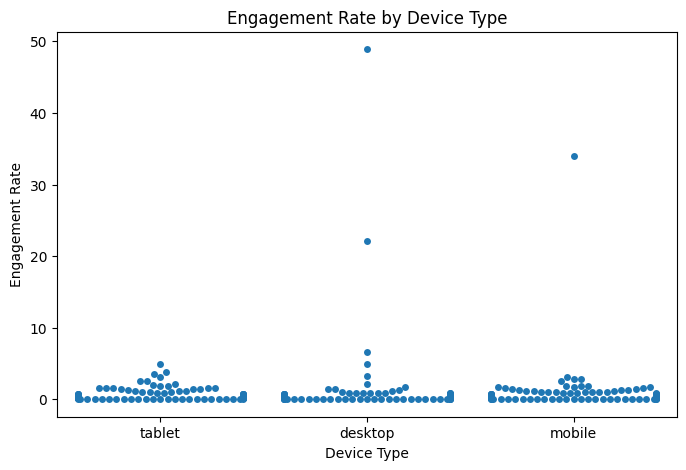

In [49]:
sample_df = df.sample(500)

plt.figure(figsize=(8, 5))

sns.swarmplot(
    data=sample_df,
    x="device_type",
    y="engagement_rate"
)

plt.title("Engagement Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Engagement Rate")
plt.show()

In [50]:
daily_engagement = (
    df.groupby(df["posted_at"].dt.date)["engagement_rate"]
    .mean()
    .reset_index()
)

daily_engagement.columns = ["date", "avg_engagement"]

In [51]:
fig = px.line(
    daily_engagement,
    x="date",
    y="avg_engagement",
    title="Interactive Daily Engagement Trend",
    markers=True
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Average Engagement Rate"
)

fig.show()

In [52]:
fig = px.scatter(
    df.sample(1000),
    x="impression_count",
    y="likes",
    size="comments",
    color="post_type",
    hover_data=["country", "post_category"],
    title="Interactive Likes vs Impressions"
)

fig.update_layout(
    xaxis_title="Impressions",
    yaxis_title="Likes"
)

fig.show()